# 단어의 분산 표현을 얻기위한 기법들
- 통계 기반 기법 (SVD)
    - 단어의 동시발생 행렬을 만들고, SVD를 적용하여 밀집벡터(분산표현)를 얻음
    - 학습데이터 전체를 한꺼번에 처리(배치). O(n^3)의 시간복잡도를 가져 현실적으로 사용하기 어려움
- 추론 기반 기법 (신경망, word2vec)
    - 주변 단어(맥락)가 주어졌을 때, 특정 위치에 어떤 단어가 들어갈 지 추론하여 단어의 분산표현을 얻음
    - 소량의 데이터(미니배치)를 반복 학습

In [1]:
import numpy as np
i = np.array([[1, 0, 0, 0, 0, 0, 0]]) # 입력 미니배치를 고려하여 2차원 (1, 7)
w = np.random.randn(7, 3) # 가중치 (7, 3)
h = np.matmul(i, w) # 히든 노드 출력 (1, 3)
print(h)

[[ 0.47262177 -1.5764786   1.15131002]]


In [2]:
# CBOW
# 맥락으로부터 타깃을 추론하는 word2vec 모델
# 학습이 완료된 후의 은닉층의 가중치 W가 단어의 분산표현
# 입력층 뉴런보다 은닉층 뉴런수를 적게 하는것이 중요. 정보를 간결하게 표현할 수 있음
# 단어의 분산표현은 일반적으로 입력측의 가중치 W_in만 사용함

from common.layers import MatMul

# 샘플 맥락 벡터
c0 = np.array([[1, 0, 0, 0, 0, 0, 0]])
c1 = np.array([[0, 0, 1, 0, 0, 0, 0]])

W_in = np.random.randn(7, 3)
W_out = np.random.randn(3, 7)

in_layer0 = MatMul(W_in)
in_layer1 = MatMul(W_in)
out_layer = MatMul(W_out)

h0 = in_layer0.forward(c0)
h1 = in_layer1.forward(c1)
h = 0.5 * (h0 + h1) # 입력 레이어 갯수 = 추론할 단어 갯수. 다음 계층으로 보낼땐 평균으로 보냄
s = out_layer.forward(h) # 추론 score

print(s)

[[-0.33871252 -1.11774145 -0.38115512 -0.03270167 -1.85949847 -1.64421089
   1.01094037]]


In [3]:
from common.util import preprocess, create_contexts_target, convert_one_hot

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

contexts, target = create_contexts_target(corpus, window_size=1)
print('# contexts\n', contexts)
print('# target\n', target)
print()

vocab_size = len(word_to_id)
contexts = convert_one_hot(contexts, vocab_size)
target = convert_one_hot(target, vocab_size)
print('# contexts onehot\n', contexts)
print('# target onehot\n', target)


# contexts
 [[0 2]
 [1 3]
 [2 4]
 [3 1]
 [4 5]
 [1 6]]
# target
 [1 2 3 4 1 5]

# contexts onehot
 [[[1 0 0 0 0 0 0]
  [0 0 1 0 0 0 0]]

 [[0 1 0 0 0 0 0]
  [0 0 0 1 0 0 0]]

 [[0 0 1 0 0 0 0]
  [0 0 0 0 1 0 0]]

 [[0 0 0 1 0 0 0]
  [0 1 0 0 0 0 0]]

 [[0 0 0 0 1 0 0]
  [0 0 0 0 0 1 0]]

 [[0 1 0 0 0 0 0]
  [0 0 0 0 0 0 1]]]
# target onehot
 [[0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0]]


In [4]:
import numpy as np
from common.layers import MatMul, SoftmaxWithLoss

class SimpleCBOW:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size

        W_in = np.random.randn(V, H).astype('f')
        W_out = np.random.randn(H, V).astype('f')

        self.in_layer0 = MatMul(W_in)
        self.in_layer1 = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer = SoftmaxWithLoss()

        layers = [self.in_layer0, self.in_layer1, self.out_layer, self.loss_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # 단어의 분산표현 저장
        self.word_vec = W_in

    def forward(self, contexts, target):
        h0 = self.in_layer0.forward(contexts[:, 0])
        h1 = self.in_layer1.forward(contexts[:, 1])
        h = (h0 + h1) * 0.5
        score = self.out_layer.forward(h)
        loss = self.loss_layer.forward(score, target)
        return loss
    
    def backward(self, dout=1):
        ds = self.loss_layer.backward(dout)
        da = self.out_layer.backward(ds)
        da *= 0.5
        self.in_layer1.backward(da)
        self.in_layer0.backward(da)
        return None


| 에폭 1 |  반복 1 / 2 | 시간 0[s] | 손실 2.13
| 에폭 2 |  반복 1 / 2 | 시간 0[s] | 손실 1.66
| 에폭 3 |  반복 1 / 2 | 시간 0[s] | 손실 2.05
| 에폭 4 |  반복 1 / 2 | 시간 0[s] | 손실 1.58
| 에폭 5 |  반복 1 / 2 | 시간 0[s] | 손실 1.91
| 에폭 6 |  반복 1 / 2 | 시간 0[s] | 손실 1.61
| 에폭 7 |  반복 1 / 2 | 시간 0[s] | 손실 1.42
| 에폭 8 |  반복 1 / 2 | 시간 0[s] | 손실 2.13
| 에폭 9 |  반복 1 / 2 | 시간 0[s] | 손실 1.85
| 에폭 10 |  반복 1 / 2 | 시간 0[s] | 손실 1.63
| 에폭 11 |  반복 1 / 2 | 시간 0[s] | 손실 1.45
| 에폭 12 |  반복 1 / 2 | 시간 0[s] | 손실 2.41
| 에폭 13 |  반복 1 / 2 | 시간 0[s] | 손실 1.58
| 에폭 14 |  반복 1 / 2 | 시간 0[s] | 손실 1.74
| 에폭 15 |  반복 1 / 2 | 시간 0[s] | 손실 1.92
| 에폭 16 |  반복 1 / 2 | 시간 0[s] | 손실 1.38
| 에폭 17 |  반복 1 / 2 | 시간 0[s] | 손실 1.74
| 에폭 18 |  반복 1 / 2 | 시간 0[s] | 손실 1.90
| 에폭 19 |  반복 1 / 2 | 시간 0[s] | 손실 1.50
| 에폭 20 |  반복 1 / 2 | 시간 0[s] | 손실 1.77
| 에폭 21 |  반복 1 / 2 | 시간 0[s] | 손실 1.76
| 에폭 22 |  반복 1 / 2 | 시간 0[s] | 손실 1.59
| 에폭 23 |  반복 1 / 2 | 시간 0[s] | 손실 1.84
| 에폭 24 |  반복 1 / 2 | 시간 0[s] | 손실 1.53
| 에폭 25 |  반복 1 / 2 | 시간 0[s] | 손실 2.00
| 에폭 26 |

/Users/user/dev/toy/dl-study/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/user/dev/toy/dl-study/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/user/dev/toy/dl-study/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/user/dev/toy/dl-study/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


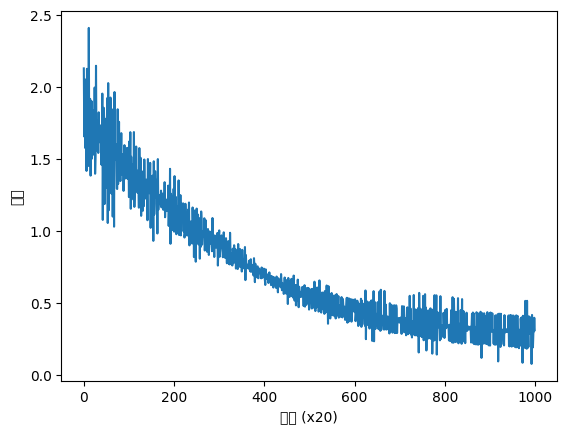

In [5]:
from common.trainer import Trainer
from common.optimizer import Adam

window_size = 1
hidden_size = 5
batch_size = 3
max_epoch = 1000

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

vocab_size = len(word_to_id)
contexts, target = create_contexts_target(corpus, window_size)
contexts = convert_one_hot(contexts, vocab_size)
target = convert_one_hot(target, vocab_size)

model = SimpleCBOW(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()



In [6]:
word_vecs = model.word_vec
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])

you [-1.956185   -1.822754   -1.2447833  -1.503556   -0.12261444]
say [-1.2646606  -1.6615926  -1.2131394  -0.97887665  0.1231717 ]
goodbye [ 0.6413621   2.7422404  -0.7967642  -0.40404877 -0.27661943]
and [-1.562538   -3.5235467   0.7117235   0.5898427  -0.09169067]
i [ 0.3376572  1.8307701 -0.5531448 -1.6847839 -1.0971286]
hello [-0.9040719   0.16927898 -2.0350547   0.3311897  -0.9279218 ]
. [ 2.776417  -0.8499758 -0.7615355  1.7654756 -2.434647 ]
